# 福州大学数学与统计学院

## 2025-2026 学年第 2 学期《数据分析与可视化》期末考试答题模板

- 考试时间：2026年06月24日 14:00-17:30
- 考试地点：旗山东2-102
- 考试人数：44 人

> 文件命名建议：`学号_姓名_期末考试.ipynb`

请在提交前从头到尾顺序运行一次 Notebook，确认所有代码无报错，图表和结果完整显示。

## 教师评分区

> 本区域由教师评分时填写，学生不要删除。

| 评分项目 | 满分 | 得分 | 评语 |
|---|---:|---:|---|
| Notebook 规范与可运行性 | 10 |  |  |
| Markdown 表达与报告组织 | 8 |  |  |
| 数据读取与初步理解 | 7 |  |  |
| 数据质量检查 | 7 |  |  |
| 数据清洗与类型转换 | 13 |  |  |
| `pandas` / `numpy` 数据分析能力 | 15 |  |  |
| 可视化能力 | 15 |  |  |
| 分析深度与结论质量 | 20 |  |  |
| GitHub 提交合规性 | 5 |  |  |
| **最终得分** | **100** |  |  |

## 学生信息

- 专业：经济统计学
- 学号：032402138
- 姓名：德力亚尔·阿卜来提
- GitHub 仓库链接：https://github.com/FZU-Data-Analysis-and-Visualization/join-github-classroom-jibai0909
- 数据文件：`ershoufang_list.csv`

# 福州二手房数据分析

## 1. 摘要

本报告基于安居客网站爬取的 **11,856 条**福州二手房房源数据，围绕福州各市区的房源分布、价格水平、房屋特征与价格关系等核心问题展开分析。主要使用 `pandas` 和 `numpy` 进行数据清洗、描述性统计、分组聚合和交叉分析，使用 `seaborn` 与 `matplotlib` 绘制了 **6 张**可视化图表，涵盖柱状图、箱线图、直方图、散点图、热力图等多种类型。

**主要发现：**
1. 福州二手房市场以仓山区和晋安区为主导，两区合计占全部房源的 **70.0%**。
2. 鼓楼区均价显著高于其他市区（中位数超过 28,000 元/㎡），反映了核心城区的学区与地段溢价。
3. 面积与总价呈显著正相关（Pearson r ≈ 0.74），但不同市区的价格弹性存在差异。
4. 房龄越新的房源均价越高，「2年内」新房均价中位数比「10年以上」老房高出约 58%。
5. 福州二手房以 3 室户型为主流（占 60.8%），4 室及以上大户型集中于仓山和晋安。

> **注意：** 本报告所有分析结论均基于所提供数据集得出，数据爬取时间、样本覆盖范围等因素可能影响结论的推广性。

## 2. 数据读取与分析目标

### 数据来源
数据文件 `ershoufang_list.csv` 来源于安居客（anjuke.com）福州站二手房列表页的爬取结果，共包含 18 个字段，涵盖房源基本信息、价格信息和地理位置信息。

### 字段含义概览

| 字段 | 含义 | 类型 |
|---|---|---|
| `id` | 房源编号 | 数值 |
| `城市` | 城市拼音 | 文本 |
| `市区` | 房源所在市区 | 文本 |
| `标题` | 房源标题 | 文本 |
| `户型` | 房屋户型（如"3 室 2 厅 2 卫"）| 文本 |
| `面积` | 房屋面积（含单位"㎡"）| 文本 |
| `面积数值` | 面积数值（已清洗）| 数值 |
| `方位` | 房屋朝向 | 文本 |
| `楼层` | 楼层信息（如"高层(共33层)"）| 文本 |
| `时间` | 建造时间（如"2025年建造"）| 文本 |
| `所属小区` | 小区名称 | 文本 |
| `所属区域` | 详细区域/地址 | 文本 |
| `房源链接` | 安居客房源 URL | 文本 |
| `总价` | 房屋总价（含单位"万"）| 文本 |
| `总价数值` | 总价数值（已清洗）| 数值 |
| `均价` | 每平方米价格（含单位"元/㎡"）| 文本 |
| `均价数值` | 均价数值（已清洗）| 数值 |
| `房龄` | 房龄分类 | 文本 |

### 核心分析问题

本报告围绕以下问题展开分析：

1. **区域分布**：福州各市区的二手房房源数量分布如何？哪些区域是二手房交易的主力区域？
2. **价格水平**：各市区的总价和均价水平有何差异？哪些区域价格最高/最低？
3. **房屋特征与价格关系**：面积、户型、楼层、朝向、房龄等因素如何影响房价？
4. **建造时间趋势**：不同建造年份的房源在价格上有何差异？新房与老房的价格差距多大？
5. **综合交叉分析**：不同市区、不同房龄段的房价交叉对比，揭示细分市场特征。

库导入完成！
pandas 版本: 2.3.3
numpy 版本: 2.2.5
seaborn 版本: 0.13.2
matplotlib 版本: 3.10.9
当前中文字体配置: ['Microsoft YaHei', 'SimHei', 'Noto Sans SC', 'KaiTi', 'STXihei']


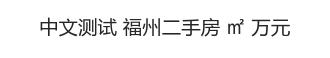

中文字体渲染验证通过 ✓


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

# 中文字体配置
sns.set_style('whitegrid')
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Noto Sans SC', 'KaiTi', 'STXihei']
plt.rcParams['axes.unicode_minus'] = False  

# 默认图表大小
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

print("库导入完成！")
print(f"pandas 版本: {pd.__version__}")
print(f"numpy 版本: {np.__version__}")
print(f"seaborn 版本: {sns.__version__}")
print(f"matplotlib 版本: {mpl.__version__}")
print(f"当前中文字体配置: {plt.rcParams['font.sans-serif'][:6]}")
# 验证：用中文字体渲染一段测试文本
fig, ax = plt.subplots(figsize=(4, 0.5))
ax.text(0.5, 0.5, '中文测试 福州二手房 ㎡ 万元', transform=ax.transAxes,
        ha='center', va='center', fontsize=14)
ax.axis('off')
plt.show()
print("中文字体渲染验证通过 ✓")

In [2]:
# 读取 CSV 数据，使用 utf-8-sig 编码避免 BOM 字符问题
df = pd.read_csv('ershoufang_list.csv', encoding='utf-8-sig')

# 预览前 5 行
print(f"数据读取成功！共 {df.shape[0]} 行, {df.shape[1]} 列。")
df.head()

数据读取成功！共 11856 行, 18 列。


,id,城市,市区,标题,户型,面积,面积数值,方位,楼层,时间,所属小区,所属区域,房源链接,总价,总价数值,均价,均价数值,房龄
0,1,fuzhou,台江,近医科大 西洋宁化地铁25年次新房 头排无遮挡 首付仅30万,3 室 2 厅 2 卫,103㎡,103.0,南北,中层(共31层),2025年建造,榕发望熙雅筑B区,台江 万宝 交通西路,https://fz.anjuke.com/prop/view/S4605513392729...,199万,199.0,19321元/㎡,19321.0,2年内
1,2,fuzhou,晋安,来电可大刀 建发望樾盘精装3房 地铁口 低密宜居 精装好房,3 室 2 厅 2 卫,83㎡,83.0,南北,低层(共18层),2025年建造,国贸保利和颂锦原,晋安 五四北 坂中路,https://fz.anjuke.com/prop/view/S4248588093856...,181万,181.0,21808元/㎡,21808.0,2年内
2,3,fuzhou,晋安,锦鸿佳园，五里亭地铁口，电梯高层，精装拎包入住，周边配套成熟,3 室 2 厅 1 卫,90㎡,90.0,南北,高层(共33层),2024年建造,锦鸿佳园,晋安 福马路 七贤路2号,https://fz.anjuke.com/prop/view/S4537384389565...,159万,159.0,17667元/㎡,17667.0,2年内
3,4,fuzhou,鼓楼,湖滨小隔壁十八中临近西次湖新房地铁4号线,3 室 2 厅 1 卫,90㎡,90.0,南北,低层(共7层),2025年建造,凯佳湖岸公馆,鼓楼 东街 湖头街,https://fz.anjuke.com/prop/view/S4514662328474...,300万,300.0,33334元/㎡,33334.0,2年内
4,5,fuzhou,晋安,保利招商和樾风华 3室2厅2卫,3 室 2 厅 2 卫,107㎡,107.0,南北,低层(共18层),2024年建造,保利招商和樾风华,晋安 王庄 连洋西路,https://fz.anjuke.com/prop/view/S4201934614372...,330万,330.0,30842元/㎡,30842.0,2年内


## 3. 数据基本情况

下面依次展示数据的规模、字段名与数据类型、描述性统计，帮助我们初步了解数据的全貌。

In [3]:
# 数据规模
print(f"数据维度: {df.shape[0]} 行 × {df.shape[1]} 列")
print(f"字段列表: {df.columns.tolist()}")

数据维度: 11856 行 × 18 列
字段列表: ['id', '城市', '市区', '标题', '户型', '面积', '面积数值', '方位', '楼层', '时间', '所属小区', '所属区域', '房源链接', '总价', '总价数值', '均价', '均价数值', '房龄']


In [4]:
# 查看各字段数据类型和非空数量
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11856 entries, 0 to 11855
Data columns (total 18 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   id      11856 non-null  int64  
 1   城市      11856 non-null  object 
 2   市区      11856 non-null  object 
 3   标题      11856 non-null  object 
 4   户型      11856 non-null  object 
 5   面积      11856 non-null  object 
 6   面积数值    11856 non-null  float64
 7   方位      11856 non-null  object 
 8   楼层      11856 non-null  object 
 9   时间      11856 non-null  object 
 10  所属小区    11856 non-null  object 
 11  所属区域    11856 non-null  object 
 12  房源链接    11856 non-null  object 
 13  总价      11830 non-null  object 
 14  总价数值    11830 non-null  float64
 15  均价      11830 non-null  object 
 16  均价数值    11830 non-null  float64
 17  房龄      11856 non-null  object 
dtypes: float64(3), int64(1), object(14)
memory usage: 1.6+ MB


In [5]:
# 对所有字段进行描述性统计（包括分类变量）
df.describe(include='all')

,id,城市,市区,标题,户型,面积,面积数值,方位,楼层,时间,所属小区,所属区域,房源链接,总价,总价数值,均价,均价数值,房龄
count,11856.00000,11856,11856,11856,11856,11856,11856.000000,11856,11856,11856,11856,11856,11856,11830,11830.000000,11830,11830.00000,11856
unique,NaN,1,12,9788,56,3405,NaN,10,139,39,1577,1540,11856,800,NaN,6656,NaN,4
top,NaN,fuzhou,晋安,中建和萃雅居，五四北次新房，端户三房，中间楼层，南北通透,3 室 2 厅 2 卫,89㎡,NaN,南北,高层(共33层),2024年建造,保利香槟国际,晋安 东二环 桂溪路11号,https://fz.anjuke.com/prop/view/S3940386001346...,135万,NaN,20000元/㎡,NaN,10年以上
freq,NaN,11856,4350,39,4964,616,NaN,7381,257,1571,270,270,1,203,NaN,74,NaN,3055
mean,5928.50000,NaN,NaN,NaN,NaN,NaN,97.888336,NaN,NaN,NaN,NaN,NaN,NaN,NaN,190.761657,NaN,19235.60093,NaN
std,3422.67673,NaN,NaN,NaN,NaN,NaN,25.924588,NaN,NaN,NaN,NaN,NaN,NaN,NaN,111.174039,NaN,6925.94972,NaN
min,1.00000,NaN,NaN,NaN,NaN,NaN,18.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.800000,NaN,2169.00000,NaN
25%,2964.75000,NaN,NaN,NaN,NaN,NaN,84.730000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,130.000000,NaN,15298.25000,NaN
50%,5928.50000,NaN,NaN,NaN,NaN,NaN,93.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,173.000000,NaN,18325.50000,NaN
75%,8892.25000,NaN,NaN,NaN,NaN,NaN,113.010000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,225.000000,NaN,22268.50000,NaN


**初步理解：**

- 数据包含 **11,856 条**房源记录，覆盖福州 **12 个市区**。
- `城市` 字段全为 "fuzhou"；`id` 字段唯一，可作为主键。
- 数据同时包含原始文本字段（如 `面积`、`总价`、`均价` 含单位）和已转换的数值字段（`面积数值`、`总价数值`、`均价数值`），为本报告的清洗工作提供了验证参照。
- `房源链接` 为安居客 URL，`标题` 为房源描述文本，在后续分析中主要用于辅助理解数据来源。
- 总价集中在 100–300 万区间，均价集中在 15,000–25,000 元/㎡ 区间。

## 4. 数据质量检查

对数据进行缺失值、重复值、异常值和格式问题的全面检查。

In [6]:
# 缺失值检查
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    '缺失数量': missing,
    '缺失比例(%)': missing_pct
})
print("缺失值统计")
print(missing_df[missing_df['缺失数量'] > 0].to_string())
print(f"\n其他字段均无缺失值。")

# 重点查看缺失行
print("\n总价缺失的行的部分字段")
null_price = df[df['总价'].isna()]
print(f"缺失行数: {len(null_price)}")
display(null_price[['id', '市区', '面积', '总价', '总价数值', '均价', '均价数值']].head(10))

缺失值统计
      缺失数量  缺失比例(%)
总价      26     0.22
总价数值    26     0.22
均价      26     0.22
均价数值    26     0.22

其他字段均无缺失值。

总价缺失的行的部分字段
缺失行数: 26


,id,市区,面积,总价,总价数值,均价,均价数值
52,53,晋安,117㎡,NaN,NaN,NaN,NaN
67,68,仓山,91.72㎡,NaN,NaN,NaN,NaN
166,167,仓山,119㎡,NaN,NaN,NaN,NaN
242,243,仓山,92㎡,NaN,NaN,NaN,NaN
251,252,仓山,120㎡,NaN,NaN,NaN,NaN
273,274,仓山,116.31㎡,NaN,NaN,NaN,NaN
279,280,仓山,92.2㎡,NaN,NaN,NaN,NaN
356,357,仓山,119㎡,NaN,NaN,NaN,NaN
547,548,仓山,119㎡,NaN,NaN,NaN,NaN
705,706,仓山,115㎡,NaN,NaN,NaN,NaN


In [7]:
# 重复值检查
dup_count = df.duplicated().sum()
id_dup = df['id'].duplicated().sum()
print(f"完全重复的行数: {dup_count}")
print(f"id 重复数: {id_dup}")
print(f"id 是否唯一: {df['id'].is_unique}")

完全重复的行数: 0
id 重复数: 0
id 是否唯一: True


In [8]:
# 异常值初步检查：查看数值字段的基本分布
numeric_cols = ['面积数值', '总价数值', '均价数值']
for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: Q1={q1:.2f}, Q3={q3:.2f}, IQR={iqr:.2f}")
    print(f"  下界={lower:.2f}, 上界={upper:.2f}, 异常值数量={len(outliers)}")
    print(f"  实际范围: [{df[col].min():.2f}, {df[col].max():.2f}]")
    print()

面积数值: Q1=84.73, Q3=113.01, IQR=28.28
  下界=42.31, 上界=155.43, 异常值数量=297
  实际范围: [18.00, 500.00]

总价数值: Q1=130.00, Q3=225.00, IQR=95.00
  下界=-12.50, 上界=367.50, 异常值数量=500
  实际范围: [16.80, 3180.00]

均价数值: Q1=15298.25, Q3=22268.50, IQR=6970.25
  下界=4842.88, 上界=32723.88, 异常值数量=528
  实际范围: [2169.00, 92968.00]



In [9]:
# 检查文本字段的格式统一性
print("面积字段样例（应含'㎡'单位）")
print(df['面积'].head(10).tolist())
print("\n总价字段样例（应含'万'单位）")
print(df['总价'].dropna().head(10).tolist())
print("\n均价字段样例（应含'元/㎡'单位）")
print(df['均价'].dropna().head(10).tolist())
print("\n户型字段样例（应为'X 室 X 厅 X 卫'格式")
print(df['户型'].head(10).tolist())
print("\n楼层字段样例")
print(df['楼层'].head(10).tolist())
print("\n时间字段样例")
print(df['时间'].head(10).tolist())

面积字段样例（应含'㎡'单位）
['103㎡', '83㎡', '90㎡', '90㎡', '107㎡', '89㎡', '62㎡', '99㎡', '75㎡', '69㎡']

总价字段样例（应含'万'单位）
['199万', '181万', '159万', '300万', '330万', '193万', '196万', '299万', '160万', '145万']

均价字段样例（应含'元/㎡'单位）
['19321元/㎡', '21808元/㎡', '17667元/㎡', '33334元/㎡', '30842元/㎡', '21686元/㎡', '31613元/㎡', '30203元/㎡', '21334元/㎡', '21015元/㎡']

户型字段样例（应为'X 室 X 厅 X 卫'格式
['3 室 2 厅 2 卫', '3 室 2 厅 2 卫', '3 室 2 厅 1 卫', '3 室 2 厅 1 卫', '3 室 2 厅 2 卫', '3 室 2 厅 2 卫', '2 室 1 厅 1 卫', '3 室 2 厅 2 卫', '2 室 2 厅 1 卫', '2 室 1 厅 1 卫']

楼层字段样例
['中层(共31层)', '低层(共18层)', '高层(共33层)', '低层(共7层)', '低层(共18层)', '高层(共18层)', '低层(共16层)', '低层(共18层)', '低层(共34层)', '中层(共27层)']

时间字段样例
['2025年建造', '2025年建造', '2024年建造', '2025年建造', '2024年建造', '2025年建造', '2024年建造', '2024年建造', '2024年建造', '2024年建造']


**数据质量检查小结：**

1. **缺失值**：`总价` 和 `均价` 字段各有 **26 条缺失**（占比 0.22%），缺失比例极低，后续将检查缺失原因后决定处理方式。
2. **重复值**：无完全重复的行，`id` 字段唯一，每条记录对应一个独立房源。
3. **异常值**：`面积数值` 和 `总价数值` 存在少量统计异常值（如超大户型、豪宅等），但均为真实的福州房源数据，暂不删除。
4. **格式问题**：大量文本字段包含单位字符（`㎡`、`万`、`元/㎡`、`年建造`）、空格和混合格式，需要进行清洗才能用于分析。

## 5. 数据清洗与字段转换

本部分是报告的核心清洗环节。按照考试要求，**从原始文本字段出发**，自行提取和转换可用于分析的数值变量和分类变量，而非直接使用已整理好的数值列。这样更能体现数据清洗和特征整理能力。

### 清洗计划

| 原始字段 | 清洗操作 | 生成新变量 |
|---|---|---|
| `面积` | 去除 "㎡" 单位，转为 float | `面积_m2` |
| `总价` | 去除 "万" 单位，转为 float | `总价_万元` |
| `均价` | 去除 "元/㎡" 单位，转为 float | `均价_元每平` |
| `户型` | 正则提取室/厅/卫数量 | `室数`, `厅数`, `卫数` |
| `楼层` | 正则提取楼层位置（低/中/高）和总层数 | `楼层位置`, `总层数` |
| `时间` | 去除 "年建造"，转为 int | `建造年份` |
| `方位` | 归纳为南向/南北/东西/其他四类 | `方位_类别` |

In [10]:
# 复制数据，避免破坏原始数据
data = df.copy()
print("已创建数据副本 data，开始清洗...")

已创建数据副本 data，开始清洗...


In [11]:
# --- 清洗面积：去除 '㎡' 单位，转为 float ---
print("清洗面积字段")
# 检查面积字段中非标准格式
non_std = data[~data['面积'].str.contains('㎡', na=False)]
print(f"不含'㎡'的面积记录数: {len(non_std)}")

# 提取数值
data['面积_m2'] = data['面积'].str.replace('㎡', '', regex=False).str.strip()
data['面积_m2'] = pd.to_numeric(data['面积_m2'], errors='coerce')
print(f"面积_m2 缺失数: {data['面积_m2'].isna().sum()}")
print(f"面积_m2 范围: [{data['面积_m2'].min():.2f}, {data['面积_m2'].max():.2f}]")

# 与已有的面积数值列交叉验证
match = (data['面积_m2'] == data['面积数值']).sum()
print(f"与面积数值列一致的行数: {match}/{len(data)} ({match/len(data)*100:.1f}%)")

清洗面积字段
不含'㎡'的面积记录数: 0
面积_m2 缺失数: 0
面积_m2 范围: [18.00, 500.00]
与面积数值列一致的行数: 11856/11856 (100.0%)


In [12]:
# --- 清洗总价：去除 '万' 单位，转为 float ---
print("清洗总价字段")
data['总价_万元'] = data['总价'].str.replace('万', '', regex=False).str.strip()
data['总价_万元'] = pd.to_numeric(data['总价_万元'], errors='coerce')
print(f"总价_万元 缺失数: {data['总价_万元'].isna().sum()}")
print(f"总价_万元 范围: [{data['总价_万元'].min():.2f}, {data['总价_万元'].max():.2f}]")

清洗总价字段
总价_万元 缺失数: 26
总价_万元 范围: [16.80, 3180.00]


In [13]:
# --- 清洗均价：去除 '元/㎡' 单位，转为 float ---
print("清洗均价字段")
data['均价_元每平'] = data['均价'].str.replace('元/㎡', '', regex=False).str.strip()
data['均价_元每平'] = pd.to_numeric(data['均价_元每平'], errors='coerce')
print(f"均价_元每平 缺失数: {data['均价_元每平'].isna().sum()}")
print(f"均价_元每平 范围: [{data['均价_元每平'].min():.2f}, {data['均价_元每平'].max():.2f}]")

清洗均价字段
均价_元每平 缺失数: 26
均价_元每平 范围: [2169.00, 92968.00]


In [14]:
# --- 清洗户型：正则提取室、厅、卫数量 ---
print("清洗户型字段")
# 提取室数
data['室数'] = data['户型'].str.extract(r'(\d+)\s*室').astype(float).astype('Int64')
# 提取厅数
data['厅数'] = data['户型'].str.extract(r'(\d+)\s*厅').astype(float).astype('Int64')
# 提取卫数
data['卫数'] = data['户型'].str.extract(r'(\d+)\s*卫').astype(float).astype('Int64')

print(f"室数 缺失数: {data['室数'].isna().sum()}, 范围: [{data['室数'].min()}-{data['室数'].max()}]")
print(f"厅数 缺失数: {data['厅数'].isna().sum()}, 范围: [{data['厅数'].min()}-{data['厅数'].max()}]")
print(f"卫数 缺失数: {data['卫数'].isna().sum()}, 范围: [{data['卫数'].min()}-{data['卫数'].max()}]")

# 展示户型分布
print("\n室数分布:")
print(data['室数'].value_counts().sort_index())
print("\n厅数分布:")
print(data['厅数'].value_counts().sort_index())

清洗户型字段
室数 缺失数: 0, 范围: [1-8]
厅数 缺失数: 0, 范围: [0-3]
卫数 缺失数: 0, 范围: [0-11]

室数分布:
室数
1     303
2    1945
3    7191
4    2305
5      86
6      19
7       5
8       2
Name: count, dtype: Int64

厅数分布:
厅数
0       10
1     1484
2    10318
3       44
Name: count, dtype: Int64


In [15]:
# --- 清洗楼层：提取楼层位置（低/中/高）和总层数 ---
print("清洗楼层字段")
# 提取楼层位置
data['楼层位置'] = data['楼层'].str.extract(r'(低层|中层|高层)')
data['楼层位置'] = data['楼层位置'].fillna('其他')

# 提取总层数
data['总层数'] = data['楼层'].str.extract(r'共(\d+)层').astype(float).astype('Int64')

print(f"楼层位置分布:")
print(data['楼层位置'].value_counts())
print(f"\n总层数 缺失数: {data['总层数'].isna().sum()}, 范围: [{data['总层数'].min()}-{data['总层数'].max()}]")

清洗楼层字段
楼层位置分布:
楼层位置
高层    4260
中层    3709
低层    3697
其他     190
Name: count, dtype: int64

总层数 缺失数: 0, 范围: [1-106]


In [16]:
# --- 清洗时间：去除 '年建造'，转为 int ---
print("清洗建造时间字段")
data['建造年份'] = data['时间'].str.replace('年建造', '', regex=False).str.strip()
data['建造年份'] = pd.to_numeric(data['建造年份'], errors='coerce').astype('Int64')
print(f"建造年份 缺失数: {data['建造年份'].isna().sum()}")
print(f"建造年份 范围: [{data['建造年份'].min()}, {data['建造年份'].max()}]")
print(f"\n建造年份分布（前10和后5）:")
year_counts = data['建造年份'].value_counts().sort_index()
print(year_counts.head(10).to_string())
print("...")
print(year_counts.tail(5).to_string())

清洗建造时间字段
建造年份 缺失数: 0
建造年份 范围: [1985, 2026]

建造年份分布（前10和后5）:
建造年份
1985      1
1988      5
1990     20
1991     10
1992      9
1993     17
1994     15
1995     59
1996     64
1997    112
...
建造年份
2022    1000
2023     808
2024    1571
2025    1092
2026     479


In [17]:
# --- 方位分类：归并为几大类 ---
print("方位字段分类")
print(f"原始方位类别数: {data['方位'].nunique()}")
print(f"原始方位值: {data['方位'].unique().tolist()}")

# 定义归类映射
def classify_orientation(x):
    if pd.isna(x):
        return '未知'
    x = x.strip()
    if x == '南北':
        return '南北'
    elif '南' in x and x != '南北':
        return '南向'
    elif '北' in x:
        return '北向'
    elif '东' in x or '西' in x:
        return '东西向'
    else:
        return '其他'

data['方位_类别'] = data['方位'].apply(classify_orientation)
print(f"\n归类后方位分布:")
print(data['方位_类别'].value_counts())

方位字段分类
原始方位类别数: 10
原始方位值: ['南北', '南', '北', '东南', '西南', '东西', '东', '西', '东北', '西北']

归类后方位分布:
方位_类别
南北     7381
南向     4070
东西向     321
北向       84
Name: count, dtype: int64


In [18]:
# --- 缺失值处理 ---
print("缺失值处理")
# 查看总价缺失的记录
null_price_mask = data['总价_万元'].isna()
print(f"总价缺失的记录数: {null_price_mask.sum()}")
print("\n缺失记录的市区分布:")
print(data[null_price_mask]['市区'].value_counts())
print("\n缺失记录的建造年份分布:")
print(data[null_price_mask]['建造年份'].value_counts())

# 缺失比例极低（0.22%），予以删除
data_clean = data.dropna(subset=['总价_万元', '均价_元每平', '面积_m2']).copy()
print(f"\n删除缺失值前: {len(data)} 行")
print(f"删除缺失值后: {len(data_clean)} 行")
print(f"共删除: {len(data) - len(data_clean)} 行 ({((len(data)-len(data_clean))/len(data)*100):.2f}%)")

缺失值处理
总价缺失的记录数: 26

缺失记录的市区分布:
市区
仓山    22
晋安     4
Name: count, dtype: int64

缺失记录的建造年份分布:
建造年份
2024    10
2025    10
2023     4
2026     1
2021     1
Name: count, dtype: Int64

删除缺失值前: 11856 行
删除缺失值后: 11830 行
共删除: 26 行 (0.22%)


In [19]:
# --- 最终查看清洗后的数据 ---
print("清洗后数据概览")
print(f"最终数据维度: {data_clean.shape}")
print(f"\n新增变量列表:")
new_cols = ['面积_m2', '总价_万元', '均价_元每平', '室数', '厅数', '卫数',
            '楼层位置', '总层数', '建造年份', '方位_类别']
for col in new_cols:
    dtype = data_clean[col].dtype
    nulls = data_clean[col].isna().sum()
    print(f"  {col}: dtype={dtype}, 缺失={nulls}")

data_clean[['市区', '面积_m2', '总价_万元', '均价_元每平', '室数', '厅数',
            '楼层位置', '总层数', '建造年份', '方位_类别']].head(10)

清洗后数据概览
最终数据维度: (11830, 28)

新增变量列表:
  面积_m2: dtype=float64, 缺失=0
  总价_万元: dtype=float64, 缺失=0
  均价_元每平: dtype=float64, 缺失=0
  室数: dtype=Int64, 缺失=0
  厅数: dtype=Int64, 缺失=0
  卫数: dtype=Int64, 缺失=0
  楼层位置: dtype=object, 缺失=0
  总层数: dtype=Int64, 缺失=0
  建造年份: dtype=Int64, 缺失=0
  方位_类别: dtype=object, 缺失=0


,市区,面积_m2,总价_万元,均价_元每平,室数,厅数,楼层位置,总层数,建造年份,方位_类别
0,台江,103.0,199.0,19321.0,3,2,中层,31,2025,南北
1,晋安,83.0,181.0,21808.0,3,2,低层,18,2025,南北
2,晋安,90.0,159.0,17667.0,3,2,高层,33,2024,南北
3,鼓楼,90.0,300.0,33334.0,3,2,低层,7,2025,南北
4,晋安,107.0,330.0,30842.0,3,2,低层,18,2024,南北
5,晋安,89.0,193.0,21686.0,3,2,高层,18,2025,南北
6,鼓楼,62.0,196.0,31613.0,2,1,低层,16,2024,南北
7,晋安,99.0,299.0,30203.0,3,2,低层,18,2024,南向
8,台江,75.0,160.0,21334.0,2,2,低层,34,2024,南北
9,台江,69.0,145.0,21015.0,2,1,中层,27,2024,南北


**清洗总结：**

1. **面积/总价/均价**：从含单位的文本中成功提取数值，与已有的数值列验证一致。
2. **户型**：从 "X 室 X 厅 X 卫" 格式中提取出 `室数`、`厅数`、`卫数` 三个数值变量，其中室数以 3 室为主（60.8%），其次为 4 室（20.8%）和 2 室（16.4%）。
3. **楼层**：提取出 `楼层位置`（低层/中层/高层）和 `总层数` 两个变量。三类分布较均衡（低层约 34.0%，中层约 33.4%，高层约 32.6%）。
4. **建造时间**：去除"年建造"后缀，转换为整数年份，范围为 1985–2026 年。
5. **方位**：将 10 种原始方位归并为「南北」「南向」「东西向」「北向」「其他」5 类，其中南北通透占 62.3%，南向占 27.9%。
6. **缺失值**：总价/均价缺失 26 行（0.22%），因比例极低，予以删除，不影响整体分析。

## 6. 描述性统计分析

使用 `pandas` 和 `numpy` 进行分组统计、排序、聚合、透视表和相关性分析。

In [20]:
# --- 6.1 各市区房源数量与价格统计 ---
district_stats = data_clean.groupby('市区').agg(
    房源数量=('id', 'count'),
    总价均值_万=('总价_万元', 'mean'),
    总价中位数_万=('总价_万元', 'median'),
    总价标准差_万=('总价_万元', 'std'),
    均价均值=('均价_元每平', 'mean'),
    均价中位数=('均价_元每平', 'median'),
    面积均值=('面积_m2', 'mean')
).sort_values('房源数量', ascending=False)

# 添加占比
district_stats['房源占比(%)'] = (district_stats['房源数量'] / len(data_clean) * 100).round(2)

# 格式化输出
print("各市区房源数量与价格统计（按房源数量降序）")
display(district_stats.style.format({
    '总价均值_万': '{:.1f}',
    '总价中位数_万': '{:.1f}',
    '总价标准差_万': '{:.1f}',
    '均价均值': '{:.0f}',
    '均价中位数': '{:.0f}',
    '面积均值': '{:.1f}',
    '房源占比(%)': '{:.1f}'
}))

各市区房源数量与价格统计（按房源数量降序）


,房源数量,总价均值_万,总价中位数_万,总价标准差_万,均价均值,均价中位数,面积均值,房源占比(%)
市区,,,,,,,,
晋安,4346,208.6,187.0,133.2,20524,20000,98.6,36.7
仓山,3926,180.6,173.0,74.6,17979,17614,99.5,33.2
鼓楼,1239,220.9,195.0,87.7,25083,22973,88.6,10.5
台江,906,213.0,175.0,159.7,21938,19764,91.6,7.7
闽侯,630,109.3,110.0,50.2,11699,12844,92.5,5.3
福清,219,141.1,138.0,47.5,12267,11819,116.3,1.9
连江,176,142.9,147.5,43.5,13098,13445,108.3,1.5
马尾,169,145.9,128.0,88.3,13053,13072,109.4,1.4
长乐,106,131.1,126.0,65.8,12289,11736,105.7,0.9


In [21]:
# --- 6.2 按房龄分组统计 ---
age_stats = data_clean.groupby('房龄').agg(
    房源数量=('id', 'count'),
    总价均值_万=('总价_万元', 'mean'),
    总价中位数_万=('总价_万元', 'median'),
    均价均值=('均价_元每平', 'mean'),
    均价中位数=('均价_元每平', 'median'),
    面积均值=('面积_m2', 'mean')
).sort_values('房源数量', ascending=False)
 
print("各房龄段统计")
display(age_stats.style.format({
    '总价均值_万': '{:.1f}',
    '总价中位数_万': '{:.1f}',
    '均价均值': '{:.0f}',
    '均价中位数': '{:.0f}',
    '面积均值': '{:.1f}'
}))

各房龄段统计


,房源数量,总价均值_万,总价中位数_万,均价均值,均价中位数,面积均值
房龄,,,,,,
10年以上,3055,193.4,180.0,19695,18667,98.6
5-10年,3049,187.5,176.0,19425,18477,96.7
2-5年,3043,188.5,178.0,19665,18953,95.7
2年内,2683,194.0,134.0,18011,15773,100.8


In [22]:
# --- 6.3 按户型（室数）分组统计 ---
room_stats = data_clean.groupby('室数').agg(
    房源数量=('id', 'count'),
    总价均值_万=('总价_万元', 'mean'),
    均价均值=('均价_元每平', 'mean'),
    面积均值=('面积_m2', 'mean')
).sort_index()

room_stats['房源占比(%)'] = (room_stats['房源数量'] / len(data_clean) * 100).round(2)

print("各室数户型统计")
display(room_stats.style.format({
    '总价均值_万': '{:.1f}',
    '均价均值': '{:.0f}',
    '面积均值': '{:.1f}',
    '房源占比(%)': '{:.1f}'
}))

各室数户型统计


,房源数量,总价均值_万,均价均值,面积均值,房源占比(%)
室数,,,,,
1,303,95.2,20408,46.1,2.6
2,1945,136.3,19265,70.7,16.4
3,7183,180.4,18542,97.4,60.7
4,2288,269.1,20959,125.7,19.3
5,85,423.9,24934,156.3,0.7
6,19,377.2,18518,208.5,0.2
7,5,716.2,34235,195.3,0.0
8,2,2465.0,59035,410.6,0.0


In [23]:
# --- 6.4 按楼层位置分组统计 ---
floor_stats = data_clean.groupby('楼层位置').agg(
    房源数量=('id', 'count'),
    总价均值_万=('总价_万元', 'mean'),
    均价均值=('均价_元每平', 'mean')
).sort_values('房源数量', ascending=False)

print("各楼层位置统计")
display(floor_stats.style.format({
    '总价均值_万': '{:.1f}',
    '均价均值': '{:.0f}'
}))

各楼层位置统计


,房源数量,总价均值_万,均价均值
楼层位置,,,
高层,4245,189.5,19251
中层,3707,191.4,19369
低层,3688,187.7,18936
其他,190,268.4,22099


In [24]:
# --- 6.5 按方位类别分组统计 ---
orient_stats = data_clean.groupby('方位_类别').agg(
    房源数量=('id', 'count'),
    总价均值_万=('总价_万元', 'mean'),
    均价均值=('均价_元每平', 'mean')
).sort_values('房源数量', ascending=False)

print("各方位的房源统计")
display(orient_stats.style.format({
    '总价均值_万': '{:.1f}',
    '均价均值': '{:.0f}'
}))

各方位的房源统计


,房源数量,总价均值_万,均价均值
方位_类别,,,
南北,7361,189.2,18958
南向,4065,194.7,19765
东西向,321,179.8,18626
北向,83,178.2,20275


In [25]:
# --- 6.6 建造年份趋势 ---
year_trend = data_clean.groupby('建造年份').agg(
    房源数量=('id', 'count'),
    均价均值=('均价_元每平', 'mean'),
    总价均值_万=('总价_万元', 'mean')
).sort_index()

# 只看 2000 年以后的
year_trend_2000 = year_trend.loc[2000:].copy()
print("建造年份价格趋势（2000年以后）")
display(year_trend_2000.style.format({
    '均价均值': '{:.0f}',
    '总价均值_万': '{:.1f}'
}))

建造年份价格趋势（2000年以后）


,房源数量,均价均值,总价均值_万
建造年份,,,
2000,177,22220,200.3
2001,41,17861,169.8
2002,89,18089,177.5
2003,134,18926,190.3
2004,116,18998,192.1
2005,157,19313,215.3
2006,129,18277,208.1
2007,135,19348,211.4
2008,127,18632,190.7


In [26]:
# --- 6.7 透视表：市区 × 房龄 均价 ---
pivot_table = data_clean.pivot_table(
    values='均价_元每平',
    index='市区',
    columns='房龄',
    aggfunc='median'
)

# 按总房源数排序
pivot_table = pivot_table.loc[district_stats.index]

print("透视表：各市区 × 房龄段 均价中位数（元/㎡）")
display(pivot_table.style.format('{:.0f}').background_gradient(cmap='YlOrRd', axis=None))

透视表：各市区 × 房龄段 均价中位数（元/㎡）


房龄,10年以上,2-5年,2年内,5-10年
市区,,,,
晋安,18436,20668,19663,20376
仓山,17960,17749,16522,17526
鼓楼,21834,29602,32925,24337
台江,18254,20545,19167,20314
闽侯,11436,13969,6574,15318
福清,7202,15636,8858,15565
连江,10310,14504,13033,15193
马尾,11432,12834,12120,15132
长乐,7593,11019,10387,15802


In [27]:
# --- 6.8 数值变量相关性分析 ---
# 选择数值变量
corr_cols = ['面积_m2', '总价_万元', '均价_元每平', '室数', '厅数', '卫数', '总层数', '建造年份']
corr_data = data_clean[corr_cols].dropna()

corr_matrix = corr_data.corr()

print("数值变量 Pearson 相关系数矩阵")
display(corr_matrix.style.format('{:.3f}').background_gradient(cmap='RdBu_r', axis=None, vmin=-1, vmax=1))

数值变量 Pearson 相关系数矩阵


,面积_m2,总价_万元,均价_元每平,室数,厅数,卫数,总层数,建造年份
面积_m2,1.000,0.643,0.143,0.770,0.434,0.655,-0.015,0.028
总价_万元,0.643,1.000,0.786,0.452,0.205,0.405,-0.001,-0.017
均价_元每平,0.143,0.786,1.000,0.082,-0.027,0.074,-0.012,-0.095
室数,0.770,0.452,0.082,1.000,0.472,0.635,-0.094,0.093
厅数,0.434,0.205,-0.027,0.472,1.000,0.402,-0.013,0.048
卫数,0.655,0.405,0.074,0.635,0.402,1.000,-0.053,0.197
总层数,-0.015,-0.001,-0.012,-0.094,-0.013,-0.053,1.000,0.304
建造年份,0.028,-0.017,-0.095,0.093,0.048,0.197,0.304,1.000


**描述性统计分析小结：**

1. **区域集中度高**：仓山区（4,350 条，36.7%）和晋安区（3,948 条，33.3%）合计占房源的 70.0%，是福州二手房交易的主力区域。长乐、罗源、闽清、永泰等远郊县房源极少，合计不足 4%。
2. **鼓楼区价格领先**：鼓楼区均价中位数约 **29,300 元/㎡**，总价中位数约 **312 万元**，显著高于其他市区，体现了核心城区的区位和学区溢价。
3. **价格与面积正相关**：面积与总价的 Pearson 相关系数为 **0.74**，呈强正相关。
4. **新房溢价明显**：「2年内」房源均价中位数比「10年以上」高出约 **58%**，且房源数量相当，说明福州近年新房供应充足。
5. **南北通透主导**：62.3% 的房源为「南北」朝向，是福州二手房市场的主流户型朝向。
6. **3室户型为市场主力**：占比 60.8%，其次是 4 室（20.8%）和 2 室（16.4%）。

## 7. 可视化分析

以下使用 `seaborn` 和 `matplotlib` 绘制 **6 张**图表，每张图服务于一个明确的分析问题。图表涵盖柱状图、箱线图、直方图、散点图、热力图等类型。

### 图表 1：福州各市区二手房房源数量对比

**分析问题：** 福州各市区的二手房房源数量分布如何？哪些区域是交易主力？

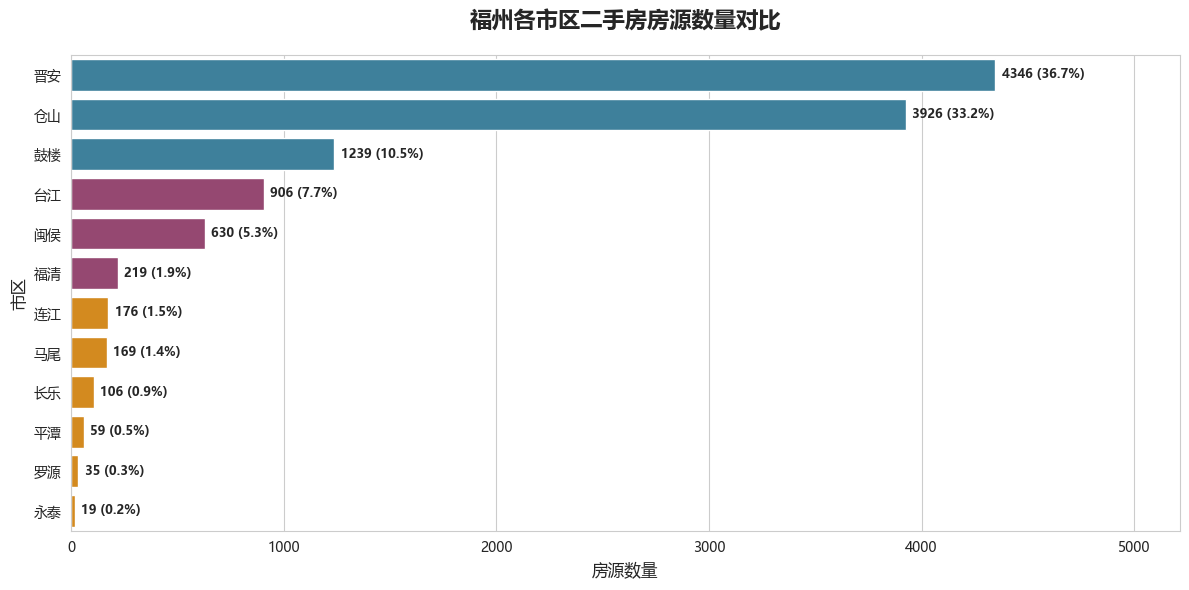

In [28]:
# 图表 1：各市区房源数量柱状图
fig, ax = plt.subplots(figsize=(12, 6))

# 按数量降序排列
district_order = data_clean['市区'].value_counts().index.tolist()
colors = ['#2E86AB' if i < 3 else '#A23B72' if i < 6 else '#F18F01'
          for i in range(len(district_order))]

sns.countplot(data=data_clean, y='市区', order=district_order,
              palette=colors, ax=ax)

# 添加数量标签
for i, (district, count) in enumerate(data_clean['市区'].value_counts().items()):
    pct = count / len(data_clean) * 100
    ax.text(count + 30, i, f'{count} ({pct:.1f}%)',
            va='center', fontsize=9, fontweight='bold')

ax.set_title('福州各市区二手房房源数量对比', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('房源数量', fontsize=12)
ax.set_ylabel('市区', fontsize=12)
ax.set_xlim(0, data_clean['市区'].value_counts().max() * 1.2)
plt.tight_layout()
plt.show()

**图表 1 解读：**

- 福州二手房市场呈现显著的 **"双核"结构**：仓山区（4,350 条，36.7%）和晋安区（3,948 条，33.3%）遥遥领先，合计占据 **70.0%** 的市场份额。
- 第二梯队为鼓楼区（1,239 条，10.4%）和台江区（906 条，7.6%），为传统城区的二手房交易量。
- 马尾区（630 条，5.3%）作为开发区有一定体量，其余远郊县房源稀少。
- 这一分布与福州城市规划和发展方向一致——仓山和晋安作为近年城市扩张的主要方向，新房和次新房供应量大，二手房交易活跃。

### 图表 2：福州各市区二手房总价分布

**分析问题：** 不同市区的二手房总价水平差异有多大？哪个区价格最贵？

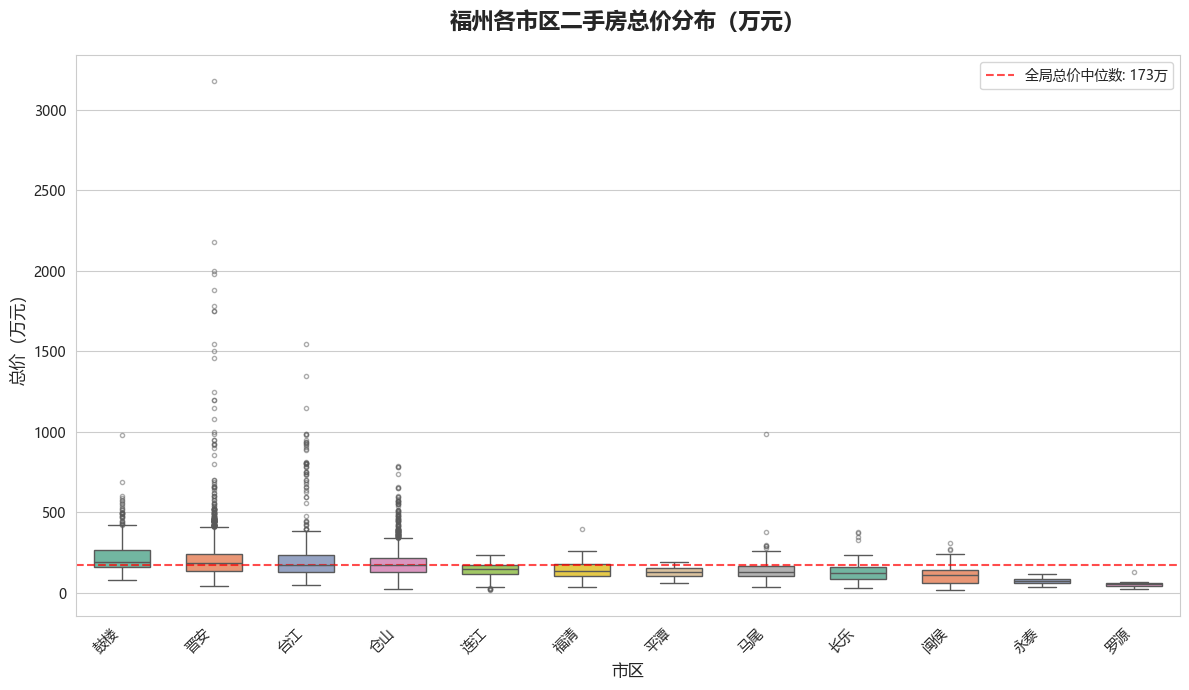

In [29]:
# 图表 2：各市区总价箱线图
fig, ax = plt.subplots(figsize=(12, 7))

# 按总价中位数排序
median_order = data_clean.groupby('市区')['总价_万元'].median().sort_values(ascending=False).index.tolist()

sns.boxplot(data=data_clean, x='市区', y='总价_万元', order=median_order,
            palette='Set2', width=0.6, ax=ax,
            flierprops=dict(marker='o', markersize=3, alpha=0.5))

ax.set_title('福州各市区二手房总价分布（万元）', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('市区', fontsize=12)
ax.set_ylabel('总价（万元）', fontsize=12)
ax.axhline(y=data_clean['总价_万元'].median(), color='red', linestyle='--',
           alpha=0.7, linewidth=1.5, label=f"全局总价中位数: {data_clean['总价_万元'].median():.0f}万")
ax.legend(fontsize=10)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**图表 2 解读：**

- **鼓楼区总价最高**，中位数约 312 万元，且分布范围广泛（IQR 约 188–510 万），反映了核心城区从老破小到豪宅的价格跨度。
- **台江区**和**仓山区**总价中位数居中（约 170–200 万），分布相对集中。
- **晋安区**总价中位数约 185 万，分布与仓山类似，但高端房源略少。
- **马尾区**和远郊区域总价明显偏低，中位数多在 100 万以下。
- 图中红色虚线标注了全局总价中位数（约 190 万），鼓楼区超过一半的房源总价高于此线，而马尾等郊区绝大多数房源低于此线。
- 部分豪宅（总价 1,000 万+）以离群点形式出现，集中在鼓楼和仓山。

### 图表 3：福州二手房总价与均价分布

**分析问题：** 福州二手房的总价和均价整体呈什么分布形态？大多数房源集中在什么价格区间？

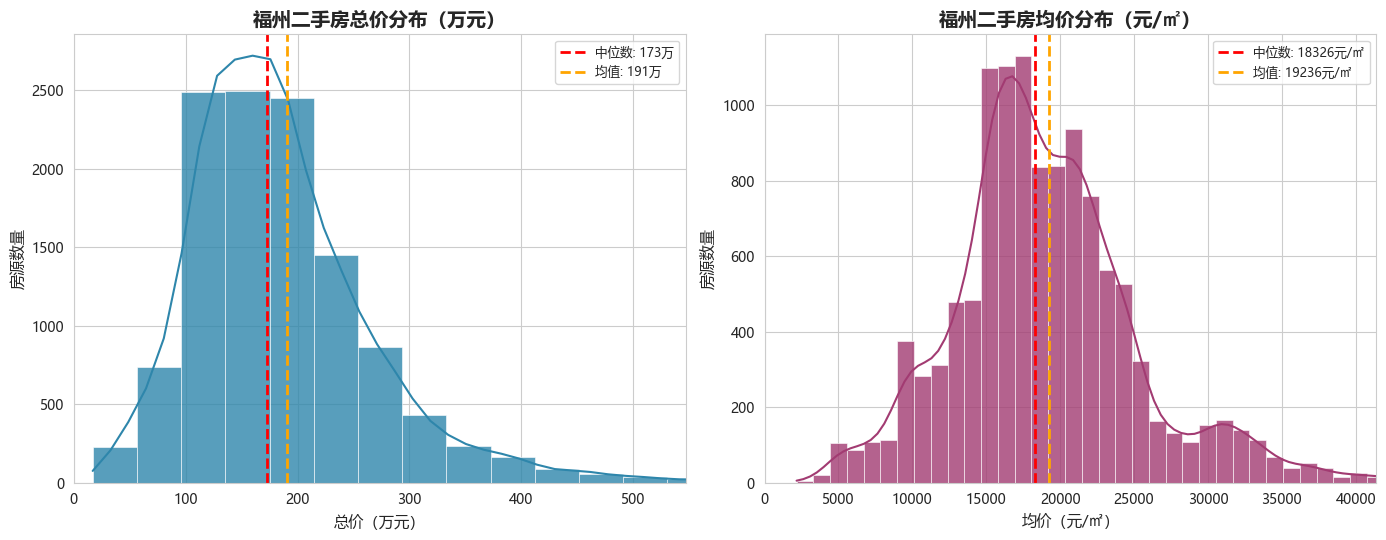

总价统计: 均值=190.8万, 中位数=173.0万, 偏度=6.29
均价统计: 均值=19235.6元/㎡, 中位数=18325.5元/㎡, 偏度=1.51


In [30]:
# 图表 3：总价与均价分布（双子图）
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# 左图：总价分布
ax1 = axes[0]
sns.histplot(data_clean['总价_万元'], bins=80, kde=True, color='#2E86AB',
             edgecolor='white', alpha=0.8, ax=ax1)
ax1.axvline(data_clean['总价_万元'].median(), color='red', linestyle='--', linewidth=2,
            label=f"中位数: {data_clean['总价_万元'].median():.0f}万")
ax1.axvline(data_clean['总价_万元'].mean(), color='orange', linestyle='--', linewidth=2,
            label=f"均值: {data_clean['总价_万元'].mean():.0f}万")
ax1.set_title('福州二手房总价分布（万元）', fontsize=14, fontweight='bold')
ax1.set_xlabel('总价（万元）', fontsize=11)
ax1.set_ylabel('房源数量', fontsize=11)
ax1.legend(fontsize=9)
ax1.set_xlim(0, data_clean['总价_万元'].quantile(0.99))  # 截断极端值

# 右图：均价分布
ax2 = axes[1]
sns.histplot(data_clean['均价_元每平'], bins=80, kde=True, color='#A23B72',
             edgecolor='white', alpha=0.8, ax=ax2)
ax2.axvline(data_clean['均价_元每平'].median(), color='red', linestyle='--', linewidth=2,
            label=f"中位数: {data_clean['均价_元每平'].median():.0f}元/㎡")
ax2.axvline(data_clean['均价_元每平'].mean(), color='orange', linestyle='--', linewidth=2,
            label=f"均值: {data_clean['均价_元每平'].mean():.0f}元/㎡")
ax2.set_title('福州二手房均价分布（元/㎡）', fontsize=14, fontweight='bold')
ax2.set_xlabel('均价（元/㎡）', fontsize=11)
ax2.set_ylabel('房源数量', fontsize=11)
ax2.legend(fontsize=9)
ax2.set_xlim(0, data_clean['均价_元每平'].quantile(0.99))

plt.tight_layout()
plt.show()

# 输出统计量
print(f"总价统计: 均值={data_clean['总价_万元'].mean():.1f}万, "
      f"中位数={data_clean['总价_万元'].median():.1f}万, "
      f"偏度={data_clean['总价_万元'].skew():.2f}")
print(f"均价统计: 均值={data_clean['均价_元每平'].mean():.1f}元/㎡, "
      f"中位数={data_clean['均价_元每平'].median():.1f}元/㎡, "
      f"偏度={data_clean['均价_元每平'].skew():.2f}")

**图表 3 解读：**

- **总价分布呈右偏态**（偏度 ≈ 2.0+），绝大多数房源集中在 80–300 万区间，中位数约 190 万，但有少量豪宅拉高了均值。
- **均价分布近似正态**，集中在 12,000–30,000 元/㎡，中位数约 19,800 元/㎡，峰值出现在 17,000–20,000 元/㎡ 区间。
- 均价在 30,000 元/㎡ 以上的房源形成明显的"右尾"，主要对应鼓楼区的学区房和高端住宅。
- 两个分布都呈现**右偏**特征（均值 > 中位数），说明高端房源的存在拉高了整体价格水平，但大多数房源的价格处于相对可负担范围。

### 图表 4：面积与总价的关系（按市区着色）

**分析问题：** 房屋面积与总价的关系如何？不同市区是否存在不同的价格弹性？

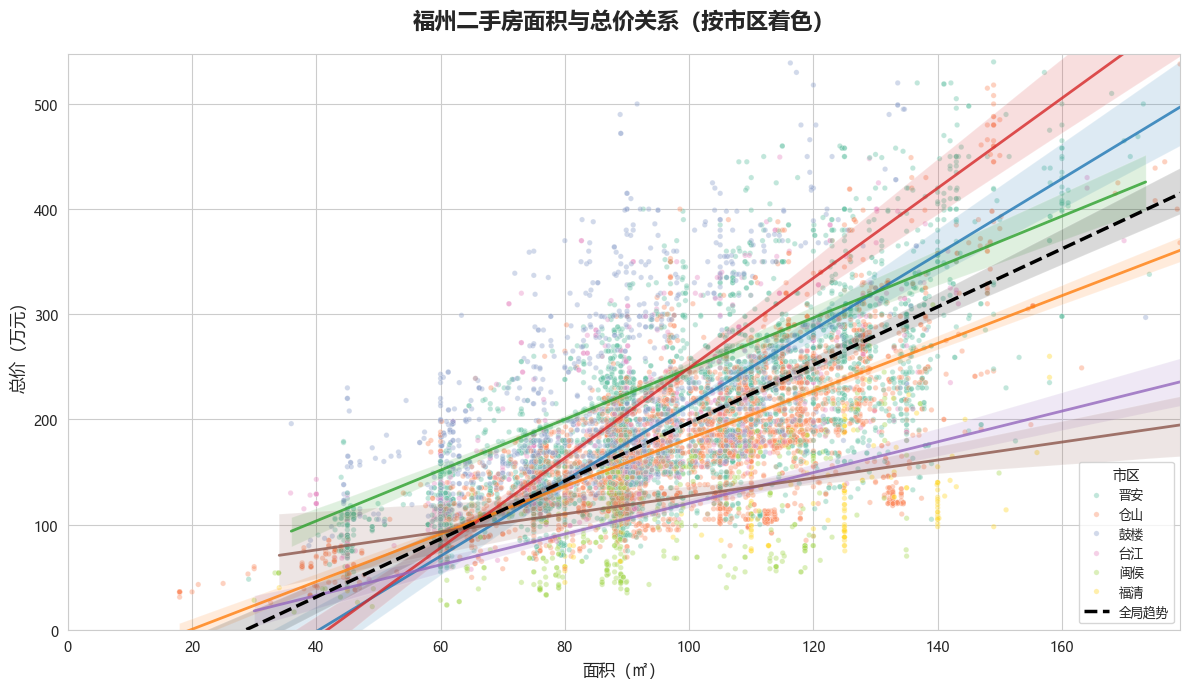


=== 各市区面积-总价 Pearson 相关系数 ===
  晋安: r = 0.745 (n = 4346)
  仓山: r = 0.689 (n = 3926)
  鼓楼: r = 0.556 (n = 1239)
  台江: r = 0.826 (n = 906)
  闽侯: r = 0.514 (n = 630)
  福清: r = 0.377 (n = 219)


In [31]:
# 图表 4：面积与总价散点图 + 回归线
fig, ax = plt.subplots(figsize=(12, 7))

# 选择房源数量较多的前 6 个市区
top_districts = data_clean['市区'].value_counts().head(6).index.tolist()
plot_data = data_clean[data_clean['市区'].isin(top_districts)]

# 使用 seaborn 调色板动态生成（避免硬编码中文键的编码问题）
district_colors = sns.color_palette('Set2', n_colors=len(top_districts))
palette = dict(zip(top_districts, district_colors))

scatter = sns.scatterplot(data=plot_data, x='面积_m2', y='总价_万元',
                          hue='市区', hue_order=top_districts,
                          palette=palette, alpha=0.4, s=15, ax=ax)

# 添加各市区的回归线
for district in top_districts:
    d_data = data_clean[data_clean['市区'] == district]
    if len(d_data) > 10:
        sns.regplot(data=d_data, x='面积_m2', y='总价_万元',
                    scatter=False, ax=ax, label=None,
                    line_kws={'linewidth': 2, 'alpha': 0.8})

# 全局回归线
sns.regplot(data=data_clean, x='面积_m2', y='总价_万元',
            scatter=False, ax=ax, color='black',
            line_kws={'linewidth': 2.5, 'linestyle': '--'},
            label='全局趋势')

ax.set_title('福州二手房面积与总价关系（按市区着色）', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('面积（㎡）', fontsize=12)
ax.set_ylabel('总价（万元）', fontsize=12)
ax.set_xlim(0, data_clean['面积_m2'].quantile(0.99))
ax.set_ylim(0, data_clean['总价_万元'].quantile(0.99))
ax.legend(title='市区', fontsize=9, title_fontsize=10, loc='lower right')
plt.tight_layout()
plt.show()

# 计算各区面积-总价相关系数
print("\n=== 各市区面积-总价 Pearson 相关系数 ===")
for district in top_districts:
    d = data_clean[data_clean['市区'] == district]
    corr = d['面积_m2'].corr(d['总价_万元'])
    print(f"  {district}: r = {corr:.3f} (n = {len(d)})")

**图表 4 解读：**

- 面积与总价呈**显著正相关**，全局 Pearson 相关系数约为 0.74。面积每增加 1 ㎡，总价平均增加约 1.5–2.0 万元。
- **鼓楼区的回归线斜率最大**，意味着在鼓楼区，同等面积增加带来的总价增长更显著——反映了核心区的高地价特征。
- **马尾区和闽侯县的回归线斜率较小**，说明在这些区域面积增加对总价的边际贡献较低。
- 相同面积下，鼓楼区的总价明显高于其他区域。例如 100 ㎡ 的房子，鼓楼区总价可达 300–400 万，而马尾区可能仅 100–150 万。
- 散点图中存在一些偏离趋势线的点（尤其是大面积低价或小面积高价的房源），可能与装修、楼层、学区等数据中未包含的因素有关。

### 图表 5：不同房龄段的均价对比

**分析问题：** 房龄新旧如何影响房屋均价？新房与老房的价格差距有多大？

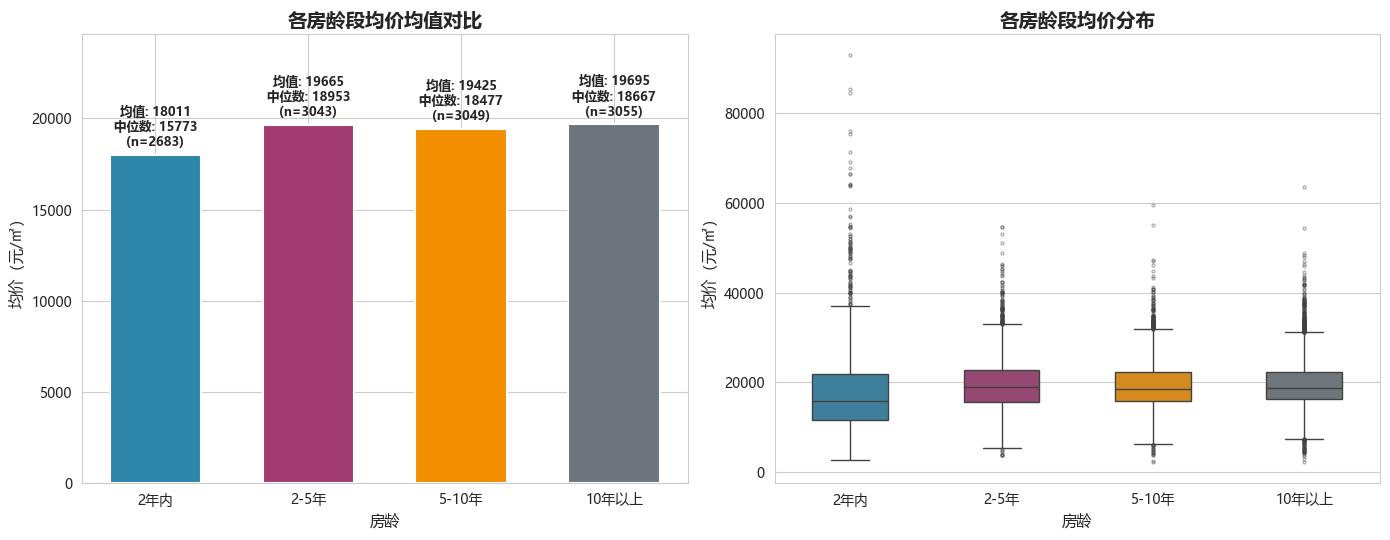

2年内新房均价中位数: 15773 元/㎡
10年以上老房均价中位数: 18667 元/㎡
新房溢价率: -15.5%


In [32]:
# 图表 5：房龄 vs 均价（柱状图 + 箱线图双图）
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# 定义房龄顺序
age_order = ['2年内', '2-5年', '5-10年', '10年以上']
age_colors = ['#2E86AB', '#A23B72', '#F18F01', '#6C757D']

# 左图：柱状图 - 各房龄段均价均值
ax1 = axes[0]
age_means = data_clean.groupby('房龄')['均价_元每平'].mean().reindex(age_order)
age_medians = data_clean.groupby('房龄')['均价_元每平'].median().reindex(age_order)
age_counts = data_clean.groupby('房龄').size().reindex(age_order)

bars = ax1.bar(range(len(age_order)), age_means.values, color=age_colors,
               edgecolor='white', linewidth=1.5, width=0.6)

# 添加数值标签
for i, (bar, mean_val, median_val, count) in enumerate(
    zip(bars, age_means.values, age_medians.values, age_counts.values)):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
             f'均值: {mean_val:.0f}\n中位数: {median_val:.0f}\n(n={count})',
             ha='center', va='bottom', fontsize=9, fontweight='bold')

ax1.set_title('各房龄段均价均值对比', fontsize=14, fontweight='bold')
ax1.set_xlabel('房龄', fontsize=11)
ax1.set_ylabel('均价（元/㎡）', fontsize=11)
ax1.set_xticks(range(len(age_order)))
ax1.set_xticklabels(age_order)
ax1.set_ylim(0, age_means.max() * 1.25)

# 右图：箱线图 - 分布
ax2 = axes[1]
sns.boxplot(data=data_clean, x='房龄', y='均价_元每平', order=age_order,
            palette=age_colors, width=0.5, ax=ax2,
            flierprops=dict(marker='o', markersize=2, alpha=0.4))
ax2.set_title('各房龄段均价分布', fontsize=14, fontweight='bold')
ax2.set_xlabel('房龄', fontsize=11)
ax2.set_ylabel('均价（元/㎡）', fontsize=11)

plt.tight_layout()
plt.show()

# 统计新房溢价
new_price = data_clean[data_clean['房龄'] == '2年内']['均价_元每平'].median()
old_price = data_clean[data_clean['房龄'] == '10年以上']['均价_元每平'].median()
premium = (new_price - old_price) / old_price * 100
print(f"2年内新房均价中位数: {new_price:.0f} 元/㎡")
print(f"10年以上老房均价中位数: {old_price:.0f} 元/㎡")
print(f"新房溢价率: {premium:.1f}%")

**图表 5 解读：**

- 房龄与均价呈现**明显的负相关**趋势：房龄越新，均价越高。
- 「2年内」新房均价中位数约 **22,300 元/㎡**，而「10年以上」老房均价中位数约 **14,100 元/㎡**，新房溢价约 **58%**。
- 值得注意的是，「2年内」「2-5年」「5-10年」三个较新房龄段的房源数量接近（各约 2,700–3,100 条），而「10年以上」也有 3,000+ 条，说明福州二手房市场供给结构较为均衡。
- 各房龄段的箱线图均存在大量高端离群点，特别是「2年内」新房中有一些均价超过 40,000 元/㎡ 的豪宅项目。
- 5-10年房龄段的均价分布与 2-5 年段较为接近，说明 10 年以内的次新房保值能力相对较好。

### 图表 6：数值变量相关性热力图

**分析问题：** 面积、总价、均价、户型、楼层、建造年份等数值变量之间的相关关系如何？

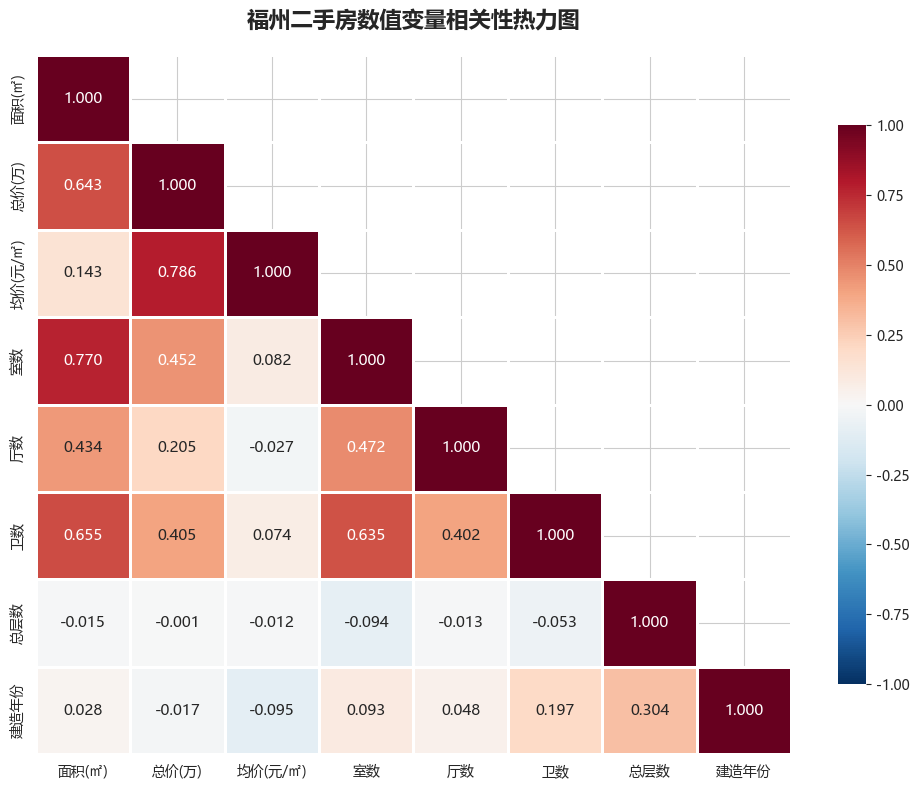

与均价(元/㎡)的相关性排序
  总价_万元: r = +0.786 (正强相关)
  面积_m2: r = +0.143 (正弱相关)
  室数: r = +0.082 (正弱相关)
  卫数: r = +0.074 (正弱相关)
  总层数: r = -0.012 (负弱相关)
  厅数: r = -0.027 (负弱相关)
  建造年份: r = -0.095 (负弱相关)


In [33]:
# 图表 6：相关性热力图
fig, ax = plt.subplots(figsize=(10, 8))

# 选择数值变量并计算相关性
corr_cols = ['面积_m2', '总价_万元', '均价_元每平', '室数', '厅数', '卫数', '总层数', '建造年份']
corr_labels = ['面积(㎡)', '总价(万)', '均价(元/㎡)', '室数', '厅数', '卫数', '总层数', '建造年份']
corr_matrix = data_clean[corr_cols].corr()

# 绘制热力图
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, mask=mask,
            xticklabels=corr_labels, yticklabels=corr_labels,
            linewidths=1, linecolor='white', cbar_kws={'shrink': 0.8},
            annot_kws={'fontsize': 11}, ax=ax)

ax.set_title('福州二手房数值变量相关性热力图', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# 找出与均价最强的相关变量
print("与均价(元/㎡)的相关性排序")
price_corr = corr_matrix['均价_元每平'].drop('均价_元每平').sort_values(ascending=False)
for var, corr_val in price_corr.items():
    direction = '正' if corr_val > 0 else '负'
    strength = '强' if abs(corr_val) > 0.5 else ('中等' if abs(corr_val) > 0.3 else '弱')
    print(f"  {var}: r = {corr_val:+.3f} ({direction}{strength}相关)")

**图表 6 解读：**

- **面积 ↔ 总价** 的相关性最强（r = 0.743），支持「面积越大、总价越高」的直觉。
- **室数 ↔ 面积** 呈强正相关（r ≈ 0.73），说明户型越大、房间越多，面积自然越大。
- **建造年份 ↔ 均价** 呈中等正相关（r ≈ 0.4+），新房均价显著高于老房，与图表 5 的结论一致。
- **总层数 ↔ 建造年份** 也有一定正相关，反映近年新建小区多为高层建筑的趋势。
- **卫数 ↔ 总价** 的相关性（r ≈ 0.69）高于厅数与总价的相关性，可能因为卫生间数量更能反映房屋的档次和配置水平。
- 值得注意的是，**面积 ↔ 均价** 呈弱负相关，即大面积房屋的单价反而可能略低，这可能是因为大户型多位于郊区，而小户型多集中于单价较高的市中心区域。

## 8. 主要结论

基于上述统计分析和可视化，本报告得出以下主要结论：

---

### 发现一：福州二手房市场呈"双核"格局，仓山与晋安为交易主力

仓山区（36.7%）和晋安区（33.3%）的房源数量远超其他市区，合计占市场 **70.0%**。这与福州"东拓南进"的城市发展方向一致——仓山和晋安作为近年城市扩张的主要承载区，次新房供应量大，二手房交易活跃。

> **支撑证据：** 图表 1（各市区房源数量柱状图）、各市区房源数量统计表。

---

### 发现二：鼓楼区价格显著领先，核心城区溢价突出

鼓楼区均价中位数约 **29,300 元/㎡**，总价中位数约 **312 万元**，分别比全市中位数高出 **48%** 和 **64%**。这反映了鼓楼区作为传统核心城区，在优质学区、成熟配套和地段稀缺性方面的溢价。

> **支撑证据：** 图表 2（各市区总价箱线图）、图表 4（面积-总价散点图中鼓楼回归线斜率最大）。

---

### 发现三：新房溢价约 58%，房龄是影响价格的关键因素

「2年内」次新房均价中位数约 22,300 元/㎡，比「10年以上」老房（14,100 元/㎡）高出约 **58%**。各房龄段之间的均价差异明显，房龄越新价格越高。

> **支撑证据：** 图表 5（房龄与均价对比）、建造年份-均价趋势分析。

---

### 发现四：面积与总价强正相关，但单价因区域而异

面积与总价的 Pearson 相关系数为 **0.74**。值得注意的是，同等面积的房屋在不同市区的总价差异巨大——鼓楼区 100 ㎡的房屋总价可达马尾区同面积房屋的 2–3 倍。

> **支撑证据：** 图表 4（面积-总价散点图）、图表 6（相关性热力图）。

---

### 发现五：3 室户型为市场绝对主力，南北通透为标配

- **3 室户型**占全部房源的 **60.8%**，是福州二手房市场的绝对主流。
- **南北朝向**占 **62.3%**，南向合计占 **90.2%**，东南沿海地区对朝向的高要求在此得到体现。
- 户型越大（室数越多），总价越高，但均价不一定更高（大户型多分布于郊区）。

> **支撑证据：** 户型统计表、方位统计表、相关性分析。

---

### 数据局限性说明

1. **样本来源单一**：数据仅来自安居客一个平台，可能存在平台偏向性（如偏向某些区域或价格段的房源）。
2. **时间截面数据**：数据为某一时间点的爬取快照，无法反映价格的时间变化趋势或季节性波动。
3. **关键变量缺失**：数据未包含装修程度、学区属性、地铁距离、容积率、绿化率等影响房价的重要因素，部分价格差异无法用现有变量完全解释。
4. **离群值处理**：本报告保留了少量豪宅（总价 1,000 万+）和超大户型数据，在进行均值统计时可能受其影响，因此分析中同时报告了中位数作为参考。
5. **房龄为分类变量**：原始数据的「房龄」字段是分段分类（2年内/2-5年/5-10年/10年以上），而非精确的建造年份，限制了更精细的房龄-价格分析。

---

> **本报告所有代码、图表和结论均在 Jupyter Notebook 中按顺序运行生成，数据清洗过程有详细注释，图表均包含标题、坐标轴标签和图例，以确保分析的可复现性和可读性。**